# RQ1 - the answer

This notebook computes nothing new. It reads what notebooks A, B, C and D measured and
answers the two halves of RQ1:

1. **how** retrieval strategy, chunking method and reranking affect the multi-metric profile;
2. **which of the three carries the largest main effect.**

### How "largest main effect" is decided
For each factor and each metric the level means are computed over the questions that every
level scored, so the comparison is paired. The effect is then summarised three ways, because
no single summary is safe on its own:

* **range** - the spread of the level means, in the metric's own units;
* **standardised range** - that spread divided by the between-question standard deviation, so
  metrics on different scales can be averaged;
* **partial eta squared** - the share of variance the factor explains once question difficulty
  is removed, from the repeated-measures decomposition.

The raw range flatters a factor with more levels: a five-level factor has more chances to
produce an extreme mean than a two-level one. The **matched contrast** is therefore also
reported - each factor's best level minus its own centre-point level, which gives every
factor exactly two levels and makes the ranking level-count independent. If the two orderings
disagree, that disagreement is the finding and is reported as such.

Everything is Holm-corrected across factors within each metric.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.2 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


## 2. Load what A, B, C and D measured

In [2]:
A = C.load_table('rq1_factorA_per_question')
B = C.load_table('rq1_factorB_per_question')
Cf = C.load_table('rq1_factorC_per_question')
G = C.load_table('rq1_generation_scored')
for name, t in [('A chunking', A), ('B retrieval', B), ('C reranking', Cf),
                ('D generation', G)]:
    print(f'{name:<16} {"missing - run that notebook" if t is None else f"{len(t):>6,} rows"}')
assert A is not None and B is not None and Cf is not None, \
    'factors A, B and C are all required'
if G is None:
    print('\nNote: without notebook D the answer covers the retrieval half of the profile only.')

A chunking        3,660 rows
B retrieval       2,440 rows
C reranking       1,220 rows
D generation      2,651 rows


## 2b. How often do the methods cut a Technote identically?

Notebook 00 found that 10% overlap adds only a few hundred segments across 28,482 Technotes, which means most documents fit inside a single 512-unit segment. On those documents the boundary-based methods produce *identical* text, so they can only differ on the remainder. This cell measures that share exactly, because it bounds how large a chunking effect this corpus can show at all - a small effect is then a property of the corpus, not evidence that segmentation does not matter.

In [3]:
def intervals_by_doc(t):
    out = {}
    for d, a, b in zip(t.doc_id.values, t.char_start.values, t.char_end.values):
        out.setdefault(d, []).append((int(a), int(b)))
    return out

tables = {}
for m in C.CFG.CHUNK_METHODS:
    f = C.PATHS.CACHE / f'chunks_{m}.parquet'
    if f.exists():
        tables[m] = intervals_by_doc(pd.read_parquet(f))
ref = tables[C.CFG.BASELINE_METHOD]
docs = sorted(ref)
single = sum(len(ref[d]) == 1 for d in docs)
agreement = {'documents': len(docs),
             'single_segment_under_centre_point': single,
             'single_segment_share': single / len(docs),
             'identical_to_centre_point': {}, 'split_share': {}}
rows = []
for m, iv in tables.items():
    same = sum(iv.get(d) == ref[d] for d in docs)
    multi = sum(len(iv.get(d, [])) > 1 for d in docs)
    agreement['identical_to_centre_point'][m] = same / len(docs)
    agreement['split_share'][m] = multi / len(docs)
    rows.append({'method': m, 'identical_to_sliding_window': same / len(docs),
                 'documents_differing': len(docs) - same,
                 'documents_split_into_several_segments': multi / len(docs)})
seg_agree = pd.DataFrame(rows)
display(seg_agree.round(4))
C.save_table(seg_agree, 'rq1_segmentation_agreement')
C.save_results(agreement, 'rq1_segmentation_agreement')
print(f"\n{100*agreement['single_segment_share']:.1f}% of candidate Technotes are a single "
      f"segment at the centre point.")

,method,identical_to_sliding_window,documents_differing,documents_split_into_several_segments
0,fixed_window,0.7198,7975,0.2802
1,sliding_window,1.0000,0,0.2802
2,recursive_structure,0.7198,7975,0.2802
3,semantic_breakpoint,0.0512,27005,0.9488
4,late_chunking,1.0000,0,0.2802


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_segmentation_agreement.csv
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_segmentation_agreement.json

72.0% of candidate Technotes are a single segment at the centre point.


## 3. The main effect of every factor on every metric

The chunking frame is restricted to the five methods of Table 2.2; the matched long-context control is a diagnostic for late chunking, not a level of the factor, so including it would inflate the factor's range.

In [5]:
A5 = A[A.method.isin(C.CFG.CHUNK_METHODS)]
frames = {'chunking_method':    (A5, 'method'),
          'retrieval_strategy': (B,  'retriever'),
          'reranking':          (Cf, 'rerank_level')}
baselines = {'chunking_method': C.CFG.BASELINE_METHOD,
             'retrieval_strategy': C.CFG.BASELINE_RETRIEVER,
             'reranking': 'off'}
PROFILE_METRICS = list(C.RETRIEVAL_METRICS)

if G is not None:
    gen_frames = {'chunking_method': ('method', G[G.factor == 'chunking_method']),
                  'retrieval_strategy': ('retriever', G[G.factor == 'retrieval_strategy']),
                  'reranking': ('rerank_level', G[G.factor == 'reranking'])}
    GEN_METRICS = [m for m in C.ANSWER_METRICS if m in G.columns]
    merged = {}
    for f, (col, gdf) in gen_frames.items():
        base_df, base_col = frames[f]
        keep = ['question_id', col] + GEN_METRICS
        merged[f] = (base_df.merge(gdf[keep], left_on=['question_id', base_col],
                                   right_on=['question_id', col], how='left',
                                   suffixes=('', '_gen')), base_col)
    frames = merged
    PROFILE_METRICS += GEN_METRICS

effects, details = C.main_effects_table(frames, PROFILE_METRICS, baselines=baselines)
display(effects[['factor', 'metric', 'n_levels', 'n_questions', 'range', 'range_lo',
                 'range_hi', 'standardised_range', 'eta2_partial', 'p_holm',
                 'significant', 'best_level_for_metric']].round(4))

# Ensure the output directory exists before saving the table
C.PATHS.OUT.mkdir(parents=True, exist_ok=True)
C.save_table(effects, 'rq1_main_effects')

,factor,metric,n_levels,n_questions,range,range_lo,range_hi,standardised_range,eta2_partial,p_holm,significant,best_level_for_metric
0,chunking_method,nDCG@5,5,610,0.0598,0.0343,0.0858,0.1444,0.0152,0.0000,True,late_chunking
1,chunking_method,Recall@20,5,610,0.0459,0.0230,0.0738,0.1380,0.0074,0.0023,True,late_chunking
2,chunking_method,MRR,5,610,0.0485,0.0240,0.0744,0.1200,0.0107,0.0001,True,late_chunking
3,chunking_method,gold_span_coverage,5,610,0.2235,0.1865,0.2611,0.5283,0.1047,0.0000,True,late_chunking
4,chunking_method,context_precision@5,5,610,0.0384,0.0305,0.0462,0.4391,0.0725,0.0000,True,late_chunking
5,chunking_method,context_recall@5,5,610,0.2235,0.1865,0.2611,0.5283,0.1047,0.0000,True,late_chunking
6,chunking_method,gold_document_in_top_5,5,610,0.0902,0.0574,0.1230,0.2098,0.0214,0.0000,True,late_chunking
7,chunking_method,chunk_boundary_loss,5,610,0.1492,0.1197,0.1803,1.1139,0.0904,0.0000,True,late_chunking
8,chunking_method,groundedness,5,132,0.0296,0.0125,0.0691,0.2743,0.0120,0.4992,False,late_chunking
9,chunking_method,faithfulness,5,132,0.0527,0.0209,0.1120,0.3051,0.0097,0.7384,False,late_chunking


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_main_effects.csv


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_main_effects.csv')

## 4. Which component carries the largest main effect?

In [6]:
ranking = C.rank_factors(effects, PROFILE_METRICS)
display(ranking.round(4))
C.save_table(ranking, 'rq1_factor_ranking')

rows = []
for factor, d in effects.dropna(subset=['matched_diff']).groupby('factor'):
    signed = d.matched_diff * d.metric.map(lambda m: C.METRIC_DIRECTION.get(m, 1))
    rows.append({'factor': factor, 'mean_matched_diff': float(signed.mean()),
                 'metrics_with_interval_excluding_zero':
                     int(((d.matched_lo > 0) | (d.matched_hi < 0)).sum()),
                 'n_metrics': int(len(d))})
matched = (pd.DataFrame(rows).sort_values('mean_matched_diff', ascending=False)
           .reset_index(drop=True))
print('\nLevel-count-independent check (best level minus that factor\'s own centre point):')
display(matched.round(4))
C.save_table(matched, 'rq1_matched_contrasts')

agree = list(ranking.factor) == list(matched.factor)
print(f"\nThe two orderings {'agree' if agree else 'DISAGREE'}:")
print('  by standardised range :', ' > '.join(ranking.factor))
print('  by matched contrast   :', ' > '.join(matched.factor))

,factor,mean_statistic,median_statistic,mean_eta2,mean_range,mean_rank,metrics_won,n_metrics
0,chunking_method,0.3273,0.2420,0.0358,0.0778,1.2143,11,14
1,retrieval_strategy,0.1747,0.1719,0.0151,0.0459,1.7857,3,14
2,reranking,0.0736,0.0763,0.0066,0.0209,3.0000,0,14


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factor_ranking.csv

Level-count-independent check (best level minus that factor's own centre point):


,factor,mean_matched_diff,metrics_with_interval_excluding_zero,n_metrics
0,chunking_method,0.0080,7,14
1,retrieval_strategy,-0.0026,0,14
2,reranking,-0.0139,6,14


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_matched_contrasts.csv

The two orderings agree:
  by standardised range : chunking_method > retrieval_strategy > reranking
  by matched contrast   : chunking_method > retrieval_strategy > reranking


  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_main_effects.png


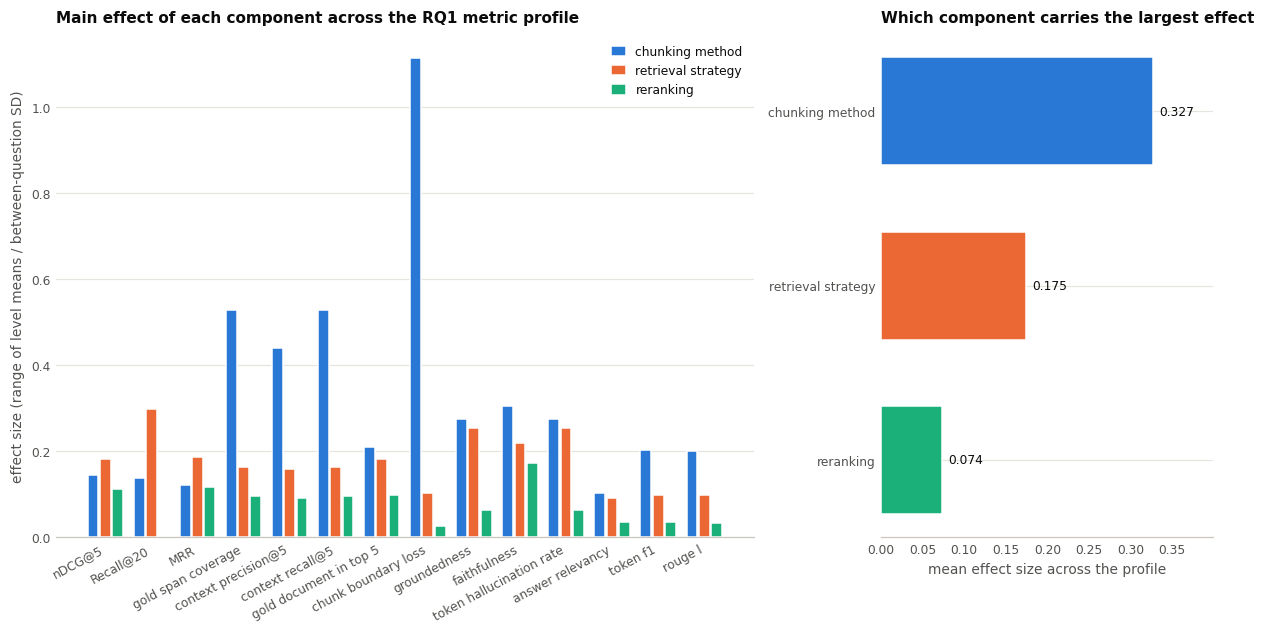

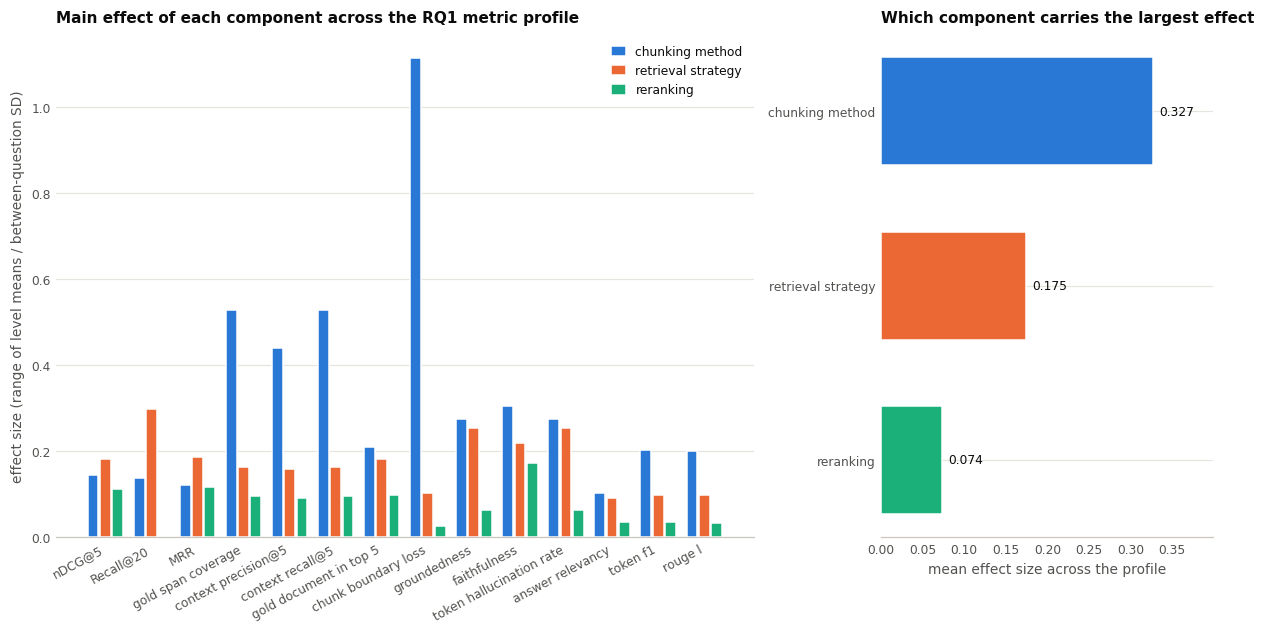

In [7]:
C.plot_effect_sizes(effects, PROFILE_METRICS, 'fig_rq1_main_effects',
    title='Main effect of each component across the RQ1 metric profile',
    caption='Left: the main effect of each pipeline component on each metric of the RQ1 '
            'profile, as the range of its level means divided by the between-question '
            'standard deviation. Right: the mean of those effects across the profile, which '
            'is the ranking that answers RQ1.')

## 5. The whole profile in one table

,factor,level,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss,groundedness,faithfulness,token_hallucination_rate,answer_relevancy,token_f1,rouge_l
0,chunking_method,fixed_window,610,0.5673,0.8361,0.5506,0.6439,0.1298,0.6439,0.6672,0.0246,0.8448,0.7894,0.1552,0.7890,0.2136,0.1924
1,chunking_method,late_chunking,610,0.6031,0.8508,0.5825,0.6882,0.1390,0.6882,0.7049,0.0180,0.8354,0.7859,0.1646,0.7869,0.2222,0.2024
2,chunking_method,recursive_structure,610,0.5685,0.8328,0.5533,0.6230,0.1256,0.6230,0.6672,0.0443,0.8385,0.7784,0.1615,0.7826,0.2237,0.1990
3,chunking_method,semantic_breakpoint,610,0.5434,0.8049,0.5340,0.4647,0.1007,0.4647,0.6148,0.1672,0.8141,0.7579,0.1859,0.7843,0.1789,0.1591
4,chunking_method,sliding_window,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262,0.8403,0.7863,0.1597,0.7868,0.2089,0.1885
5,retrieval_strategy,bm25,610,0.4987,0.7213,0.4827,0.5780,0.1170,0.5780,0.5902,0.0148,0.8229,0.7590,0.1771,0.7828,0.1892,0.1671
6,retrieval_strategy,dense,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262,0.8403,0.7863,0.1597,0.7868,0.2089,0.1885
7,retrieval_strategy,hybrid_rrf,610,0.5429,0.8262,0.5318,0.6165,0.1236,0.6165,0.6328,0.0197,0.8330,0.7822,0.1670,0.7803,0.1870,0.1719
8,retrieval_strategy,hybrid_weighted,610,0.5726,0.8033,0.5559,0.6476,0.1308,0.6476,0.6623,0.0180,0.8147,0.7632,0.1853,0.7860,0.2004,0.1814
9,reranking,cross_encoder,610,0.5243,0.8246,0.5077,0.6016,0.1216,0.6016,0.6246,0.0230,0.8460,0.8202,0.1540,0.7874,0.2007,0.1811


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_full_profile.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_profile_heatmap.png


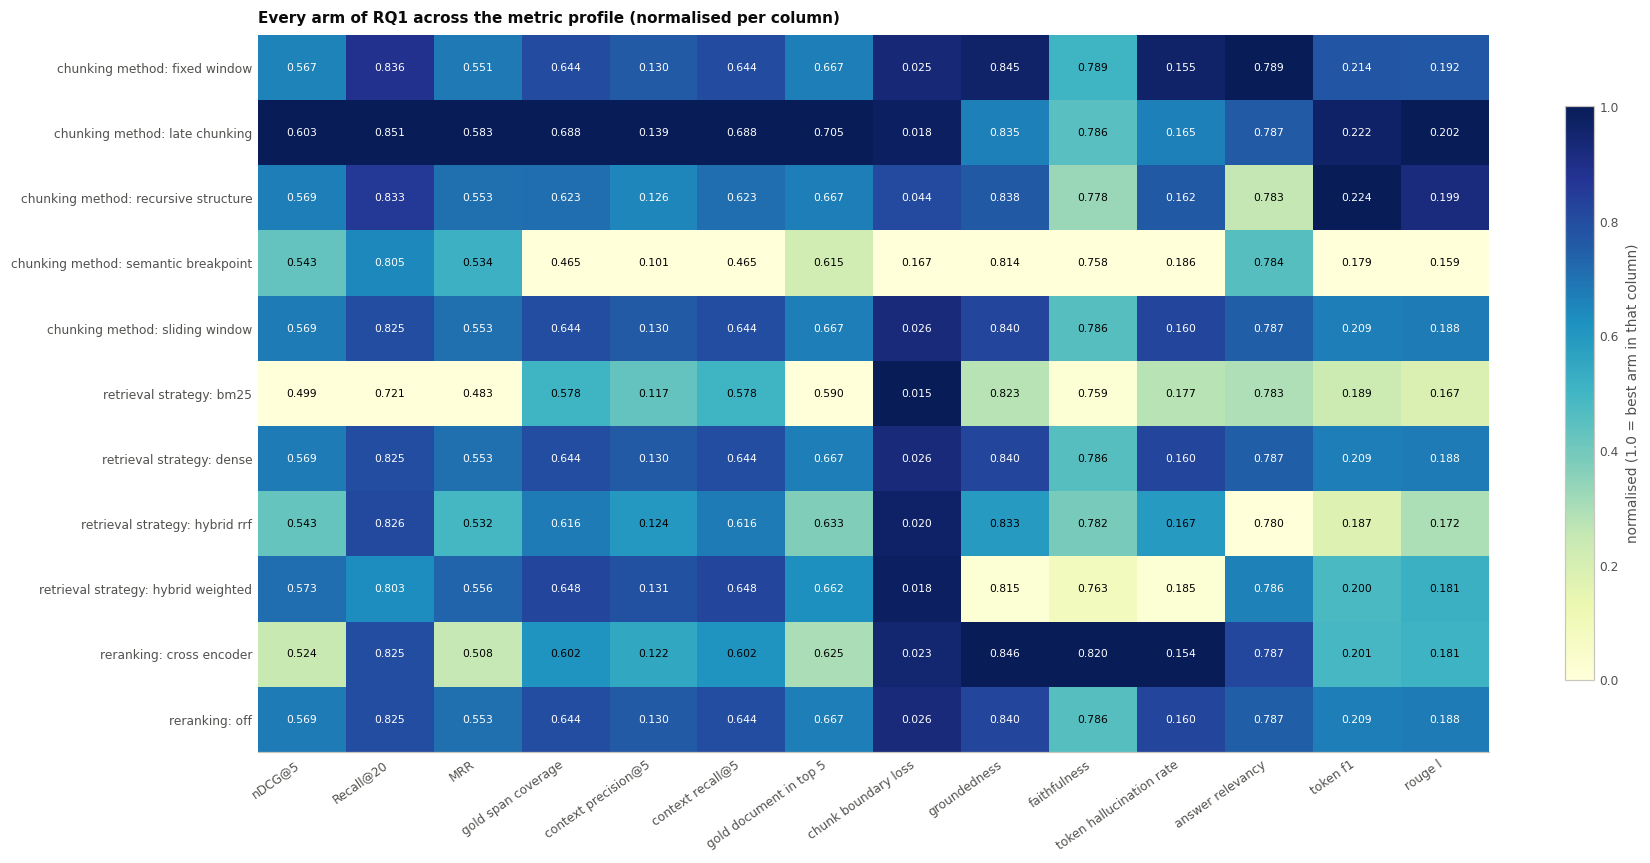

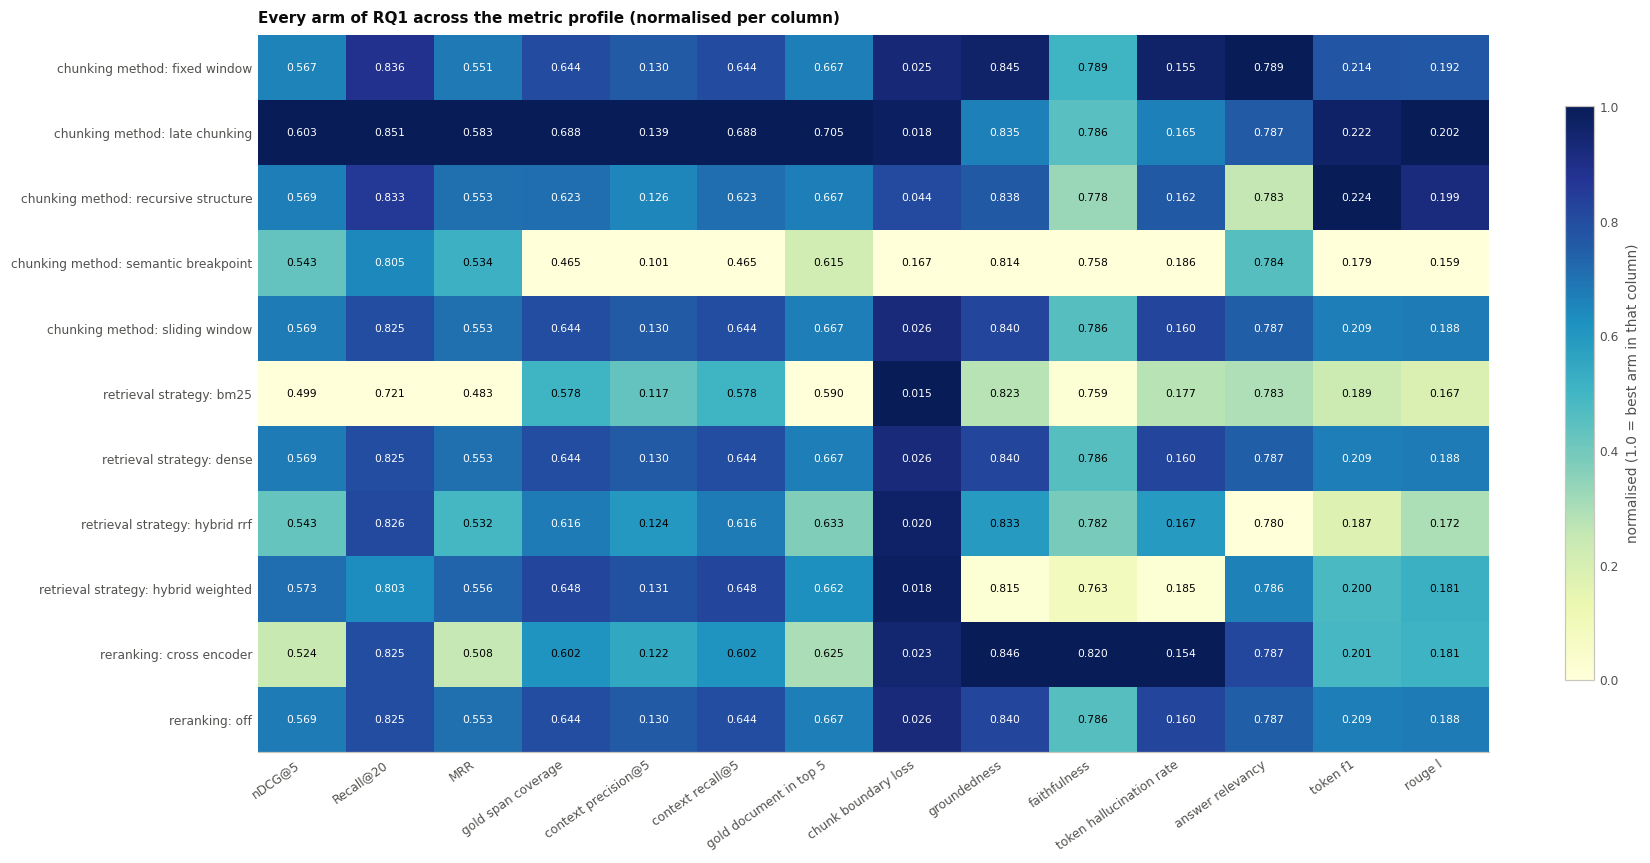

In [8]:
rows = []
for factor, (df, col) in frames.items():
    s = C.arm_summary(df, [col], PROFILE_METRICS)
    s = s.rename(columns={col: 'level'})
    s.insert(0, 'factor', factor)
    rows.append(s)
profile = pd.concat(rows, ignore_index=True)
profile['arm'] = profile.factor.str.replace('_', ' ') + ': ' + profile.level.astype(str)
display(profile[['factor', 'level', 'n'] + PROFILE_METRICS].round(4))
C.save_table(profile, 'rq1_full_profile')
C.plot_heatmap(profile, 'arm', PROFILE_METRICS, 'fig_rq1_profile_heatmap',
    'Every arm of RQ1 across the metric profile (normalised per column)',
    caption='Every level of every RQ1 factor across the metric profile. Each column is '
            'min-max normalised in the direction of improvement, so 1.0 is always the best '
            'arm in that column; printed values are the raw means.')

## 6. The answer to RQ1

Every number below is read from the computed results. Nothing here is typed by hand.

In [9]:
answer = C.answer_rq1(effects, ranking, headline_metric='nDCG@5')
answer['matched_ordering'] = list(matched.factor)
answer['orderings_agree'] = bool(agree)
answer['profile_metrics'] = PROFILE_METRICS
answer['n_questions_retrieval'] = int(A.question_id.nunique())
answer['n_questions_generation'] = int(G.question_id.nunique()) if G is not None else 0
answer['generation_profile'] = (C.load_results('rq1_generation') or {}).get('profile')
C.save_results(answer, 'rq1_answer')

top = answer['largest_main_effect']
print('=' * 92)
print('RQ1: which component carries the largest main effect?')
print('=' * 92)
print(f"\n  {top.replace('_',' ').upper()}, with a mean standardised effect of "
      f"{answer['largest_main_effect_statistic']:.3f} across "
      f"{len(PROFILE_METRICS)} metrics.")
print(f"  Runner-up: {str(answer['runner_up']).replace('_',' ')} at "
      f"{answer['runner_up_statistic']:.3f} (margin {answer['margin']:.3f}).")
print(f"  It carries the largest effect on {answer['metrics_won'].get(top, 0)} of "
      f"{len(PROFILE_METRICS)} metrics.")
print(f"  Level-count-independent check: {'same ordering' if agree else 'DIFFERENT ordering'}.")
print('\n  On nDCG@5 specifically:')
for h in answer['headline_order']:
    star = '*' if h['p_holm'] is not None and h['p_holm'] < 0.05 else ' '
    print(f"    {star} {h['factor']:<20} range {h['range']:.4f} "
          f"[{h['range_ci'][0]:.4f}, {h['range_ci'][1]:.4f}]  "
          f"eta2 {h['eta2_partial']:.4f}  best: {h['best_level']}")
print('\n  * = significant after Holm correction across factors')

  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_answer.json
RQ1: which component carries the largest main effect?

  CHUNKING METHOD, with a mean standardised effect of 0.327 across 14 metrics.
  Runner-up: retrieval strategy at 0.175 (margin 0.153).
  It carries the largest effect on 11 of 14 metrics.
  Level-count-independent check: same ordering.

  On nDCG@5 specifically:
    * retrieval_strategy   range 0.0739 [0.0539, 0.1051]  eta2 0.0245  best: hybrid_weighted
    * chunking_method      range 0.0598 [0.0343, 0.0858]  eta2 0.0152  best: late_chunking
    * reranking            range 0.0450 [0.0157, 0.0733]  eta2 0.0156  best: off

  * = significant after Holm correction across factors


## 7. The numbers the write-up needs

This writes `rq1_report_numbers.json` and a Markdown draft of the results section with every value substituted from the computed results. Download both; the local script `insert_rq1_into_report.py` turns them into the Chapter 5 section.

In [10]:
def m(factor, metric, col='range'):
    r = effects[(effects.factor == factor) & (effects.metric == metric)]
    return float(r[col].iloc[0]) if len(r) else float('nan')

numbers = {
    'answer': answer,
    'effects': effects.to_dict(orient='records'),
    'ranking': ranking.to_dict(orient='records'),
    'matched': matched.to_dict(orient='records'),
    'profile': profile.to_dict(orient='records'),
    'contrasts': {
        'chunking':  C.load_records('rq1_factorA_contrasts'),
        'retrieval': C.load_records('rq1_factorB_contrasts'),
        'reranking': C.load_records('rq1_factorC_contrasts'),
    },
    'late_chunking':    C.load_records('rq1_factorA_late_chunking'),
    'complementarity':  C.load_results('rq1_factorB_complementarity'),
    'promotion':        C.load_results('rq1_factorC_promotion'),
    'chunk_statistics': C.load_records('rq1_chunk_statistics'),
    'cost': {
        'build':      C.load_records('rq1_build_cost'),
        'factorA':    C.load_records('rq1_factorA_cost'),
        'factorB':    C.load_records('rq1_factorB_cost'),
        'factorC':    C.load_records('rq1_factorC_cost'),
        'generation': C.load_records('rq1_generation_cost'),
    },
    'abstention':         C.load_records('rq1_abstention'),
    'readability':        C.load_records('rq1_readability'),
    'generation_summary': {f: C.load_records(f'rq1_generation_summary_{f}')
                           for f in ('chunking_method', 'retrieval_strategy', 'reranking')},
    'dataset':            C.load_results('e1_dataset_validation'),
    'segmentation_agreement': C.load_results('rq1_segmentation_agreement'),
    'reproduction_check': C.load_records('rq1_factorB_reproduction_check'),
    'figures': sorted(p.name for p in C.PATHS.FIG.glob('fig_rq1_*.png')),
    'provenance': C.stamp({'stage': 'synthesis'}),
}
C.save_results(numbers, 'rq1_report_numbers')
print('\nDownload these two files and the figures folder:')
print(' ', C.PATHS.OUT / 'rq1_report_numbers.json')
print(' ', C.PATHS.OUT / 'rq1_answer.json')
print(' ', C.PATHS.FIG)

  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_report_numbers.json

Download these two files and the figures folder:
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_report_numbers.json
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_answer.json
  /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures


In [11]:
# Zip everything the write-up needs into one download.
import shutil
bundle = C.PATHS.ROOT / 'rq1_results_bundle'
shutil.make_archive(str(bundle), 'zip', str(C.PATHS.OUT))
print('bundle:', str(bundle) + '.zip',
      f'({(bundle.with_suffix(".zip")).stat().st_size/1024**2:.1f} MB)')
try:
    from google.colab import files
    files.download(str(bundle) + '.zip')
except Exception as e:
    print('download it from the Drive folder instead:', e)

bundle: /content/drive/MyDrive/techqa_rq1/rq1_results_bundle.zip (4.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Worked example behind each result

Every table and figure above is an average over hundreds of questions. The cells below take **one real question** through the same calculation, so the reader can see how a single row becomes the number that is reported. Nothing is recomputed: the values are read back from the files this notebook wrote.

The last cell answers RQ1 from a single question, so the division of labour the chapter reports can be read off one case as well as off the averages.

In [12]:
%%writefile /content/drive/MyDrive/techqa_rq1/example_cases.py
"""
example_cases.py - one real worked example behind every result and every figure.

Each function takes a single question (or a single answer) from the saved result files and
walks it through the calculation the surrounding table or figure aggregates, so a reader can
see how one row becomes the number that is reported. Nothing here computes a new result: every
value is read back from the files the notebooks wrote.

    chunking_example      what each chunking method leaves of one question's gold span
    retrieval_example     one question under the four retrievers
    reranking_example     one question with and without the cross-encoder
    effects_example       one main-effect contrast, recomputed from the paired column
    generation_example    one generated answer, its citations and its correctness check
    attribution_example   one question through the four stage tests, in pipeline order
    prompt_example        the same question under both prompts, with its stage label fixed
    certainty_example     one question's signals, its cross-fitted score and its band
    citation_example      one answer's citation pattern and the band it earns
    rq1_scenario          RQ1 answered from a single question
    rq2_scenario          RQ2 answered from a single question
    rq3_scenario          RQ3 answered from the two ends of the certainty scale

Every function prints a short block and returns the row it used, so a notebook cell can show
the example directly under the result it explains.

    import example_cases as EX
    EX.chunking_example(RESULTS)
"""
from __future__ import annotations

from pathlib import Path

import pandas as pd

WIDTH = 78
CENTRE_METHOD = "sliding_window"


def _rule(title):
    print("\n" + "-" * WIDTH)
    print(f"WORKED EXAMPLE  |  {title}")
    print("-" * WIDTH)


def _read(results, name):
    p = Path(results) / name
    if not p.exists():
        raise FileNotFoundError(f"{p} is missing; run the notebook that writes it first")
    return pd.read_csv(p)


def _pick(frame, prefer=None):
    """A stable choice: the named question if present, else the first by identifier."""
    if prefer is not None and (frame.question_id == prefer).any():
        return prefer
    return sorted(frame.question_id.unique())[0]


# ---------------------------------------------------------------------------------
# RQ1: the three factors
# ---------------------------------------------------------------------------------

def chunking_example(results, question_id=None):
    """One question seen by all five chunking methods, with the centre point first."""
    f = _read(results, "rq1_factorA_per_question.csv")
    # a question the methods disagree about makes the sharpest example, chosen over the four
    # methods that share BGE-small so the difference is segmentation and not the encoder
    same_encoder = f[~f.method.isin(["late_chunking", "sliding_window_longctx"])]
    spread = (same_encoder.groupby("question_id").gold_span_coverage
              .agg(lambda s: s.max() - s.min()).sort_values(ascending=False))
    qid = question_id or (spread.index[0] if len(spread) else _pick(f))
    rows = f[f.question_id == qid].set_index("method")
    _rule(f"chunking method, question {qid}")
    print("How much of this question's gold span each segmentation leaves in the context,")
    print("with the same retriever and the same context depth:\n")
    for method in rows.index:
        r = rows.loc[method]
        print(f"  {method:<24} coverage {float(r.gold_span_coverage):.3f}   "
              f"nDCG@5 {float(r['nDCG@5']):.3f}   "
              f"gold document in context: {'yes' if float(r.gold_document_in_top_5) else 'no'}")
    best, worst = rows.gold_span_coverage.idxmax(), rows.gold_span_coverage.idxmin()
    print(f"\n  The spread on this one question, {float(rows.gold_span_coverage.max()):.3f} under "
          f"{best} against\n  {float(rows.gold_span_coverage.min()):.3f} under {worst}, is one "
          "row of the average the table reports.")
    return rows


def retrieval_example(results, question_id=None):
    f = _read(results, "rq1_factorB_per_question.csv")
    qid = question_id or _pick(f)
    rows = f[f.question_id == qid].set_index("retriever")
    _rule(f"retrieval strategy, question {qid}")
    print("The same question and the same segmentation, scored by each retriever:\n")
    for r_ in rows.index:
        r = rows.loc[r_]
        rank = r.gold_doc_rank
        print(f"  {r_:<18} gold document rank {('-' if pd.isna(rank) else int(rank)):>3}   "
              f"Recall@20 {float(r['Recall@20']):.0f}   coverage {float(r.gold_span_coverage):.3f}")
    print("\n  Recall@20 counts only whether the document arrived; coverage says how much of")
    print("  the answer came with it, which is why both are reported.")
    return rows


def reranking_example(results, question_id=None):
    f = _read(results, "rq1_factorC_per_question.csv")
    changed = f.pivot_table(index="question_id", columns="rerank_level",
                            values="gold_span_coverage", aggfunc="first").dropna()
    if {"off", "cross_encoder"} <= set(changed.columns):
        moved = changed[changed.off != changed.cross_encoder]
        qid = question_id or (moved.index[0] if len(moved) else _pick(f))
    else:
        qid = question_id or _pick(f)
    rows = f[f.question_id == qid].set_index("rerank_level")
    _rule(f"reranking, question {qid}")
    print("The candidate list is identical; only the order in which it is cut to five differs:\n")
    for level in rows.index:
        r = rows.loc[level]
        print(f"  reranking {level:<14} gold document in context: "
              f"{'yes' if float(r.gold_document_in_top_5) else 'no ':<3}   "
              f"coverage {float(r.gold_span_coverage):.3f}   "
              f"context precision {float(r['context_precision@5']):.3f}")
    return rows


def effects_example(results, measure="gold_span_coverage", level="semantic_breakpoint"):
    """The contrast behind one cell of the main-effects table, recomputed from the rows."""
    f = _read(results, "rq1_factorA_per_question.csv")
    a = f[f.method == CENTRE_METHOD].set_index("question_id")[measure]
    b = f[f.method == level].set_index("question_id")[measure]
    both = pd.concat([a.rename("centre"), b.rename("level")], axis=1).dropna()
    diff = both.level - both.centre
    _rule(f"main effect, {level} against the centre point on {measure}")
    print(f"  questions paired            {len(both)}")
    print(f"  mean under {CENTRE_METHOD:<16} {both.centre.mean():.4f}")
    print(f"  mean under {level:<16} {both.level.mean():.4f}")
    print(f"  paired difference           {diff.mean():+.4f}")
    print(f"  questions worse / unchanged / better  "
          f"{int((diff < 0).sum())} / {int((diff == 0).sum())} / {int((diff > 0).sum())}")
    worst = diff.idxmin()
    print(f"\n  The largest single loss is {worst}: {both.loc[worst, 'centre']:.3f} -> "
          f"{both.loc[worst, 'level']:.3f}.")
    print("  The table reports the mean of this column with a bootstrap interval; the figure")
    print("  plots it. This is the column itself.")
    return both


# ---------------------------------------------------------------------------------
# generation and attribution
# ---------------------------------------------------------------------------------

def generation_example(results, answers="rq1_generation_answers.csv",
                       scored="rq1_generation_scored.csv", config_id=None, question_id=None,
                       chars=420):
    """One generated answer: what it cited, what it scored and whether the check passed."""
    a = _read(results, answers)
    s = _read(results, scored)
    cfg = config_id or sorted(a.config_id.unique())[0]
    sub = a[(a.config_id == cfg) & a.answerable.astype(str).str.lower().isin(["true", "1"])]
    qid = question_id or _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    sc = s[(s.question_id == qid) & (s.config_id == cfg)]
    _rule(f"one generated answer, question {qid}, configuration {cfg}")
    print(f"  segments given to the model : {row.segment_ids}")
    text = str(row.answer).strip().replace("\n", "\n    ")
    print(f"  answer:\n    {text[:chars]}{'...' if len(text) > chars else ''}")
    if len(sc):
        r = sc.iloc[0]
        print(f"\n  cited segments {int(r.n_cited)}   groundedness {float(r.groundedness):.3f}   "
              f"faithfulness {float(r.faithfulness):.3f}")
        print(f"  token F1 {float(r.token_f1):.3f}   abstained: "
              f"{'yes' if bool(r.abstained) else 'no'}")
        print(f"  the correctness check of Section 5.6 passes at token F1 >= 0.15, so this "
              f"answer {'passes' if float(r.token_f1) >= 0.15 else 'fails'}.")
    return row


def attribution_example(results, question_id=None, configuration=None, threshold=0.80):
    """One question walked through the four tests, in the order the pipeline runs them."""
    import rq2_core as R2
    frames = R2.load_traces(results)
    ceiling = R2.load_ceiling(results)
    table, _ = R2.configuration_table(frames, ceiling)
    cfg = configuration or R2.CENTRE
    sub = table[table.configuration == cfg]
    stages = R2.attribute(sub, threshold)
    qid = question_id or _pick(sub[stages.values != "R"]) if (stages.values != "R").any() \
        else _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    stage = R2.attribute(sub[sub.question_id == qid], threshold).iloc[0]
    ceil = float(row[R2.CEILING])
    in20 = str(row.gold_document_in_top_20).lower() in ("1", "1.0", "true", "yes")
    in5 = str(row.gold_document_in_top_5).lower() in ("1", "1.0", "true", "yes")
    cov = float(row.gold_span_coverage)
    _rule(f"stage attribution, question {qid}, {cfg}")
    tests = [
        ("1  does the segmentation still allow 80% of the span?",
         f"ceiling {ceil:.3f}", ceil >= threshold, "S1 segmentation loss"),
        ("2  is the gold Technote among the top-20 candidates?",
         "yes" if in20 else "no", in20, "S2 retrieval miss"),
        ("3  do the chosen segments carry 80% of the span?",
         f"in context: {'yes' if in5 else 'no'}, coverage {cov:.3f}",
         in5 and cov >= threshold, "S3 context exclusion"),
    ]
    for label, observed, passed, fail_label in tests:
        mark = "pass" if passed else "FAIL"
        print(f"  {label:<52} {observed:<28} {mark}")
        if not passed:
            print(f"\n  -> {fail_label}. No test below this one is read.")
            break
    else:
        print(f"  {'4  the evidence was delivered':<52} {'reachable':<28} pass")
        print("\n  -> any failure here is S4 generation drift, which needs a judged answer.")
    print(f"\n  the rule returns: {stage}")
    return row


def prompt_example(results, question_id=None):
    """The same question under both prompts, with every stage label unchanged."""
    o = _read(Path(results) / "rq2", "rq2_generation_outcomes.csv")
    sub = o[o.configuration == o.configuration.iloc[0]]
    qid = question_id or _pick(sub)
    row = sub[sub.question_id == qid].iloc[0]
    _rule(f"prompt comparison, question {qid}")
    print(f"  attributed stage : {row.stage}   (identical under both prompts: retrieval did "
          "not change)")
    print(f"  second run       : abstained {bool(row.abstained)}, correct {bool(row.correct)}, "
          f"outcome {row.outcome}")
    print("\n  Figure 5.12 aggregates exactly this: the stage label is fixed by retrieval, and")
    print("  only the answer column moves when the prompt changes.")
    return row


# ---------------------------------------------------------------------------------
# RQ3: certainty
# ---------------------------------------------------------------------------------

def certainty_example(rq3_dir, question_id=None, split="dev"):
    """One question's signals, the score they produce and the band it lands in."""
    import json
    import rq3_core as R3
    sig = _read(rq3_dir, "rq3_signals.csv")
    res = json.loads((Path(rq3_dir) / "rq3_results.json").read_text(encoding="utf-8"))
    features = res["features"]
    scores = R3.cross_fitted_scores(sig, features)
    sub = sig[sig.split == split]
    qid = question_id or _pick(sub)
    row = sig[sig.question_id == qid].iloc[0]
    p = float(scores.loc[scores.question_id == qid, "score"].iloc[0])
    band = next(b for c, b in zip(list(R3.BAND_CUTS) + [1.01], R3.BANDS) if p < c)
    _rule(f"certainty score, question {qid} ({split} split)")
    print("  the signals a deployed system could compute for this question:")
    for f in features:
        print(f"    {R3.SIGNAL_NAMES.get(f, f):<38} {float(row[f]):+.4f}")
    print(f"\n  score from the model fitted on the other split : {p:.3f}")
    print(f"  band                                           : {band}")
    print(f"  what actually happened                         : evidence "
          f"{'reached' if float(row.label_evidence) else 'did not reach'} the generator")
    print("  (which stage blocked it is RQ2's rule, not this score's: see attribution_example)")
    return row


def citation_example(rq3_dir, band="high"):
    """One answer's citation pattern, the band it earns and whether it passed the check."""
    path = Path(rq3_dir) / "rq3_citation_test_answers.csv"
    if not path.exists():
        _rule("citation band")
        print("  The out-of-sample citation test has not been run in this workspace, so there")
        print("  is no answer to show. It needs notebook D's answers; run the cell headed")
        print("  'The citation rule on answers it was not derived from' above, then this one.")
        return None
    a = _read(rq3_dir, "rq3_citation_test_answers.csv")
    sub = a[a.band == band]
    row = sub.iloc[0]
    _rule(f"citation band, one {band}-band answer")
    print(f"  question {row.question_id}, configuration {row.config_id}")
    print(f"  cited segments {int(row.n_cited)}   cites the top-ranked document: "
          f"{'yes' if bool(row.cites_top_document) else 'no'}   abstained: "
          f"{'yes' if bool(row.abstained) else 'no'}")
    print(f"  -> band {row.band}")
    print(f"  token F1 {float(row.token_f1):.3f}, so the correctness check "
          f"{'passes' if bool(row.correct) else 'fails'}.")
    print("\n  Table 5.15 counts these outcomes band by band over the 150 questions the rule")
    print("  was not derived from.")
    return row


# ---------------------------------------------------------------------------------
# One scenario per research question: a single question, followed from end to end, so the
# answer to the question can be read off a case instead of an average.
# ---------------------------------------------------------------------------------

def rq1_scenario(results, question_id=None):
    """RQ1: which component decides whether the evidence arrives?"""
    f = _read(results, "rq1_factorA_per_question.csv")
    b = _read(results, "rq1_factorB_per_question.csv")
    same_encoder = f[~f.method.isin(["late_chunking", "sliding_window_longctx"])]
    spread = (same_encoder.groupby("question_id").gold_span_coverage
              .agg(lambda s: s.max() - s.min()).sort_values(ascending=False))
    qid = question_id or spread.index[0]
    ch = same_encoder[same_encoder.question_id == qid].set_index("method")
    re_ = b[b.question_id == qid].set_index("retriever")
    _rule(f"RQ1 scenario: question {qid}")
    print("RQ1 asks which component most decides the quality of the evidence the generator\n"
          "receives. Watch one question travel the pipeline twice.\n")
    print("  Changing the SEGMENTATION, retriever fixed:")
    for m in ch.index:
        print(f"    {m:<24} the context holds {float(ch.loc[m].gold_span_coverage):.0%} "
              f"of the gold answer")
    print("\n  Changing the RETRIEVER, segmentation fixed:")
    for r_ in re_.index:
        rank = re_.loc[r_].gold_doc_rank
        print(f"    {r_:<24} gold document rank "
              f"{'not retrieved' if pd.isna(rank) else int(rank):<14} "
              f"context holds {float(re_.loc[r_].gold_span_coverage):.0%}")
    print("\n  Read together: the retriever decides whether the right Technote arrives at all,")
    print("  and the segmentation decides how much of the answer arrives with it. That is the")
    print("  split Section 5.5 reports over all 610 questions, and why RQ1 is answered by a")
    print("  division of labour rather than by a single winning component.")
    return ch


def rq2_scenario(results, question_id=None, configuration=None):
    """RQ2: what does a stage label say that an aggregate score cannot?"""
    import rq2_core as R2
    frames = R2.load_traces(results)
    ceiling = R2.load_ceiling(results)
    table, _ = R2.configuration_table(frames, ceiling)
    cfg = configuration or R2.CENTRE
    sub = table[table.configuration == cfg].reset_index(drop=True)
    stages = R2.attribute(sub)
    blocked = sub[stages.values != "R"]
    qid = question_id or _pick(blocked if len(blocked) else sub)
    _rule(f"RQ2 scenario: question {qid}, {cfg}")
    print("RQ2 asks whether a failed answer can be blamed on one stage, and whether that\n"
          "changes what an engineer would do next.\n")
    attribution_example(results, question_id=qid, configuration=cfg)
    shares = stages.value_counts(normalize=True)
    reach = float(shares.get("R", 0.0))
    print(f"\n  An aggregate score would record one more wrong answer and stop there. The rule")
    print(f"  says which stage owes the fix, and counting the labels over all "
          f"{len(sub)} questions")
    print(f"  puts a ceiling on the generator: {reach:.1%} of questions have their evidence")
    print(f"  delivered, so no change to the model alone can do better than that.")
    return sub


def rq3_scenario(rq3_dir, question_id=None):
    """RQ3: can the system tell, without gold labels, when to trust its own answer?"""
    _rule("RQ3 scenario: two questions, one trustworthy and one not")
    print("RQ3 asks whether signals available at query time can sort answers into bands that\n"
          "mean something. Here are the two ends of the scale.\n")
    import json
    import rq3_core as R3
    sig = _read(rq3_dir, "rq3_signals.csv")
    res = json.loads((Path(rq3_dir) / "rq3_results.json").read_text(encoding="utf-8"))
    scores = R3.cross_fitted_scores(sig, res["features"]).set_index("question_id")
    dev = sig[sig.split == "dev"].copy()
    dev["score"] = scores.reindex(dev.question_id).score.to_numpy()
    top = dev.sort_values("score").dropna(subset=["score"])
    for label, row in (("lowest score", top.iloc[0]), ("highest score", top.iloc[-1])):
        band = next(b for c, b in zip(list(R3.BAND_CUTS) + [1.01], R3.BANDS)
                    if float(row.score) < c)
        print(f"  {label:<14} question {row.question_id}: score {float(row.score):.2f} "
              f"-> band {band}")
        print(f"    top segment stands {float(row.dense_z_top1):+.1f} SD above the rest of the "
              f"pool; dense and lexical retrieval agree on "
              f"{float(row.agree_top5):.0%} of the context")
        print(f"    what actually happened: the evidence "
              f"{'reached' if float(row.label_evidence) else 'did not reach'} the generator\n")
    print("  The band is computed with no gold annotation, which is what makes it usable by a")
    print("  system that has none: it decides when to answer and when to hold back. Section 5.7")
    print("  reports how often that decision is right on questions the model never saw.")
    return dev


ALL = {"chunking": chunking_example, "retrieval": retrieval_example,
       "reranking": reranking_example, "effects": effects_example,
       "generation": generation_example, "attribution": attribution_example,
       "prompt": prompt_example, "certainty": certainty_example,
       "citation": citation_example, "rq1": rq1_scenario, "rq2": rq2_scenario,
       "rq3": rq3_scenario}


Overwriting /content/drive/MyDrive/techqa_rq1/example_cases.py


In [13]:
import sys, importlib
if '/content/drive/MyDrive/techqa_rq1' not in sys.path:
    sys.path.insert(0, '/content/drive/MyDrive/techqa_rq1')
import example_cases as EX
EX = importlib.reload(EX)

In [14]:
_ = EX.rq1_scenario(C.PATHS.OUT)


------------------------------------------------------------------------------
WORKED EXAMPLE  |  RQ1 scenario: question DEV_Q244
------------------------------------------------------------------------------
RQ1 asks which component most decides the quality of the evidence the generator
receives. Watch one question travel the pipeline twice.

  Changing the SEGMENTATION, retriever fixed:
    fixed_window             the context holds 100% of the gold answer
    sliding_window           the context holds 100% of the gold answer
    recursive_structure      the context holds 0% of the gold answer
    semantic_breakpoint      the context holds 0% of the gold answer

  Changing the RETRIEVER, segmentation fixed:
    bm25                     gold document rank 19             context holds 0%
    dense                    gold document rank 4              context holds 100%
    hybrid_rrf               gold document rank 9              context holds 0%
    hybrid_weighted          gold docu

In [15]:
_ = EX.effects_example(C.PATHS.OUT)


------------------------------------------------------------------------------
WORKED EXAMPLE  |  main effect, semantic_breakpoint against the centre point on gold_span_coverage
------------------------------------------------------------------------------
  questions paired            610
  mean under sliding_window   0.6436
  mean under semantic_breakpoint 0.4647
  paired difference           -0.1789
  questions worse / unchanged / better  139 / 460 / 11

  The largest single loss is TRAIN_Q000: 1.000 -> 0.000.
  The table reports the mean of this column with a bootstrap interval; the figure
  plots it. This is the column itself.


In [16]:
_ = EX.chunking_example(C.PATHS.OUT)


------------------------------------------------------------------------------
WORKED EXAMPLE  |  chunking method, question DEV_Q244
------------------------------------------------------------------------------
How much of this question's gold span each segmentation leaves in the context,
with the same retriever and the same context depth:

  fixed_window             coverage 1.000   nDCG@5 0.431   gold document in context: yes
  sliding_window           coverage 1.000   nDCG@5 0.431   gold document in context: yes
  recursive_structure      coverage 0.000   nDCG@5 0.500   gold document in context: yes
  semantic_breakpoint      coverage 0.000   nDCG@5 0.387   gold document in context: no
  late_chunking            coverage 0.000   nDCG@5 0.000   gold document in context: no
  sliding_window_longctx   coverage 0.000   nDCG@5 0.000   gold document in context: no

  The spread on this one question, 1.000 under fixed_window against
  0.000 under recursive_structure, is one row of the av